# Fitting Spectra

**Why spectra matter.** A 200-pixel spectrum constrains ~40× more information
than 5-band photometry, breaking the age–dust–metallicity degeneracy that
plagues broadband fits. Absorption features (Balmer jump, metal indices) and
Balmer decrement isolate dust, age, and Z separately — something photometry
alone cannot do. This notebook shows you end-to-end spectroscopic SED fitting
with tengri: mock generation, parametric and stochastic SFH recovery,
photometry-vs-spectroscopy comparison, SNR sensitivity, and redshift effects.

**What you'll see:** posterior corner plots with tight constraints on age,
dust, and metallicity; residuals that reveal systematics; SFH recovery at
10–100 Myr timescales; and why stochastic burstiness matters for young systems.

**Why tengri.** The same differentiable SED model handles photometry,
spectroscopy, and multi-wavelength data jointly — avoiding code duplication
and drift between fitting paths. See [`07_fitting_photometry.py`](07_fitting_photometry.py)
for photometry-only, [`14_joint_photometry_spectroscopy.py`](14_joint_photometry_spectroscopy.py)
for joint fitting, and [`11_population.py`](11_population.py) for hierarchical stacks.

**Prereqs:** [`00_quickstart.py`](00_quickstart.py) (HMC + NSS basics),
[`07_fitting_photometry.py`](07_fitting_photometry.py) (photometry setup).
**Continue with:** [`09_degeneracies.py`](09_degeneracies.py) (Fisher analysis),
[`11_population.py`](11_population.py) (hierarchical inference).

In [1]:
import os
import sys
import time
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import importlib.util

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

from tengri import (
    Fitter,
    Fixed,
    SEDModel,
    Observation,
    Parameters,
    Photometry,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

FIGDIR = os.path.join("notebooks", "figures", "fitting_spectra")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    SPECTRAL_FEATURES,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

W0422 23:03:18.861112 22754826 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## Setup

**Run Mode:** Set `RUN_EXPENSIVE = False` to complete fits in <2 min on CPU.
Set `True` to run all comparison fits (geoVI, Laplace, Pathfinder multi-iteration;
stochastic SFH recovery). Toggle this flag to explore the full notebook at your own pace.

In [2]:
RUN_EXPENSIVE = False

In [3]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
FILTER_NAMES = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]
obs_joint = Observation(
    photometry=Photometry.from_names(FILTER_NAMES),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS),
)
obs_phot = Observation(photometry=Photometry.from_names(FILTER_NAMES))
obs_spec = Observation(spectroscopy=Spectroscopy(wave_obs=WAVE_OBS))

## Inference Methods Glossary

**MAP** (maximum a posteriori): point estimate at the posterior peak; fast
initialization and diagnostic. **geoVI** (geometric variational inference via
NIFTy): normalizing-flow approximation to the posterior using geodesic flow
matching; expressive but slower. **MGVI** (mixed Gaussian VI): simpler Gaussian
posterior approximation; faster, less flexible. **Laplace**: Hessian-based
Gaussian approximation at MAP; very fast. **Pathfinder** (Zhang et al. 2022):
quasi-Newton approximation following the L-BFGS path; fast and often more
accurate than Laplace. **Posterior predictive**: samples from p(y_new | data),
accounting for posterior uncertainty; essential for residual analysis and
model checking.

For full HMC + Nested Sampling tutorial, see [`00_quickstart.py`](00_quickstart.py);
for hierarchical stochastic inference, see [`11_population.py`](11_population.py).

### Spectral resolution effects

Low-resolution spectroscopy (R = λ/Δλ < 1000) blurs absorption features
and blends emission lines:

- **R < 500:** Balmer lines merge with adjacent [N II]/[O III]; only broadband
  SED shape constrains age and dust. Similar to photometry.
- **R ~ 1000–3000:** Individual lines resolved; metallicity, dust, and age
  separable from Balmer decrement and metal-line indices.
- **R > 5000:** Velocity dispersion measurable; detailed abundance patterns.

The `resolution` parameter in `Spectroscopy(...)` sets the instrumental
line-spread function (LSF) FWHM in Å. The model convolves predictions
to match before computing the likelihood.

In [4]:
# Parametric model (D = 7)
spec_param = Parameters(
    sfh_db_log_total_mass=Uniform(8, 12),
    sfh_db_log_sfr_inst=Uniform(-2, 3),
    sfh_db_tx_frac_0=Uniform(0.05, 0.95),
    sfh_db_tx_frac_1=Uniform(0.05, 0.95),
    sfh_db_tx_frac_2=Uniform(0.05, 0.95),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="dense_basis",
)
model_param = SEDModel(spec_param, ssp_data, observation=obs_joint)
model_param_spec = SEDModel(spec_param, ssp_data, observation=obs_spec)

key = jax.random.PRNGKey(42)
true_param = spec_param.sample(key)
# Override dense_basis to a typical star-forming galaxy (still forming stars now)
true_param = {**true_param}
true_param["sfh_db_log_total_mass"] = jnp.array(10.5)
true_param["sfh_db_log_sfr_inst"] = jnp.array(0.8)
true_param["sfh_db_tx_frac_0"] = jnp.array(0.25)
true_param["sfh_db_tx_frac_1"] = jnp.array(0.35)
true_param["sfh_db_tx_frac_2"] = jnp.array(0.4)
mock_spec = model_param.mock_spectrum(true_param, WAVE_OBS, snr=30.0, key=key)
mock_phot = model_param.mock(true_param, snr=20.0, key=jax.random.fold_in(key, 1))

/Users/suchethacooray/Projects/tengri/src/tengri/forward/sed_model.py:517: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()


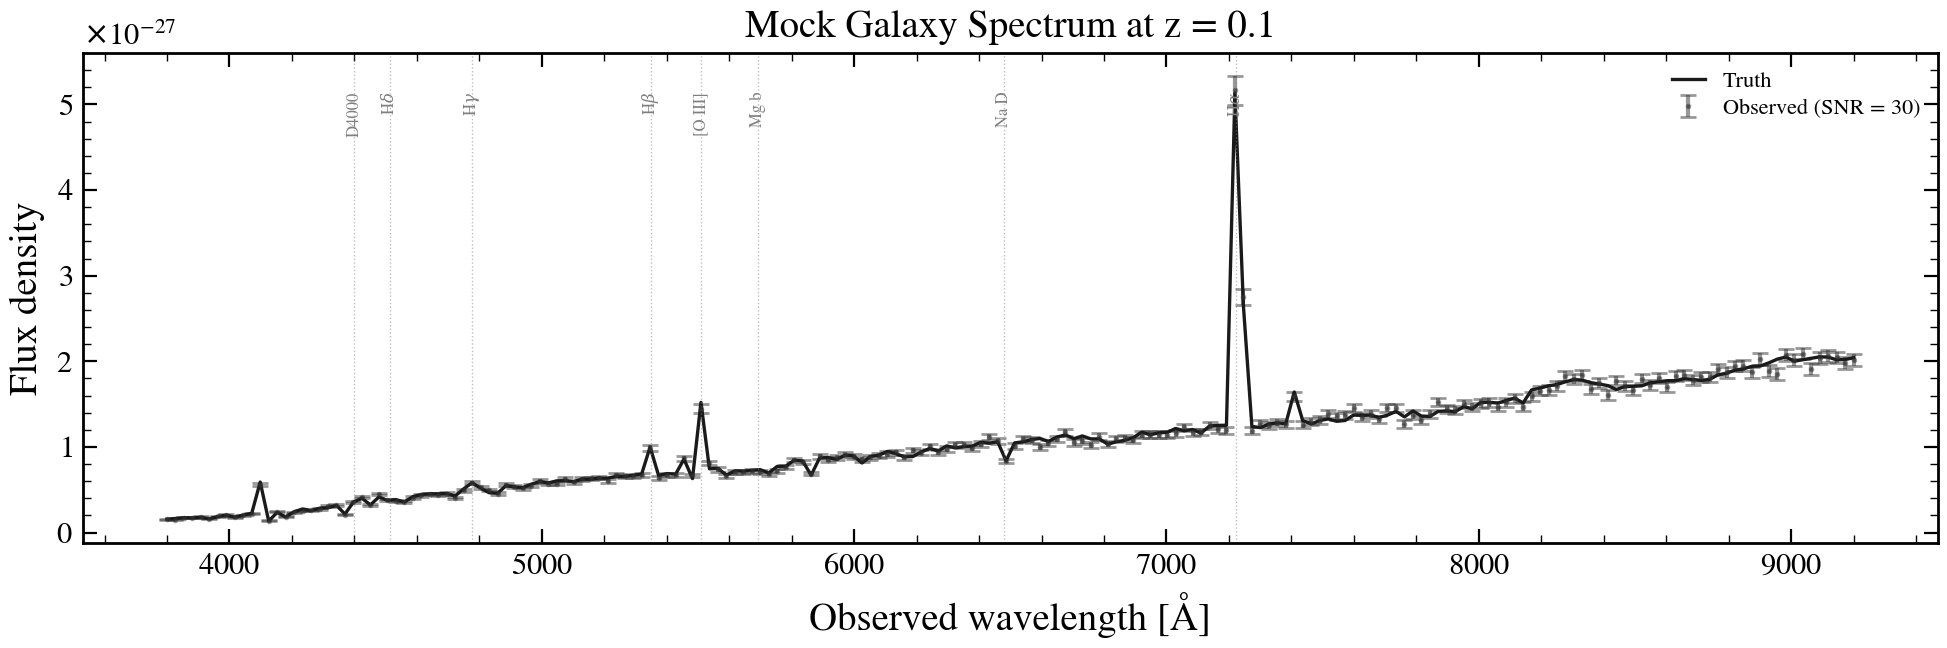

In [5]:
# --- FIGURE 1: Mock spectrum with annotated features ---
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.errorbar(
    np.array(WAVE_OBS),
    np.array(mock_spec.flux_obs),
    yerr=np.array(mock_spec.noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.5,
    label="Observed (SNR = 30)",
)
ax.plot(
    np.array(WAVE_OBS), np.array(mock_spec.flux_true), color=COLORS["truth"], lw=1.2, label="Truth"
)

for feat_name, feat_wave in SPECTRAL_FEATURES.items():
    w_obs = feat_wave * 1.1  # z = 0.1
    if 3800 < w_obs < 9200:
        ax.axvline(w_obs, color="grey", ls=":", lw=0.5, alpha=0.5)
        ax.text(
            w_obs,
            ax.get_ylim()[1] * 0.92,
            feat_name,
            fontsize=6,
            ha="center",
            va="top",
            rotation=90,
            color="grey",
        )

ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("Flux density")
ax.legend(fontsize=8)
ax.set_title("Mock Galaxy Spectrum at z = 0.1")
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig01_mock_spectrum.png"), dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Fit parametric model with vi (geoVI)
fitter_spec = Fitter(model_param_spec, mock_spec.flux_obs, mock_spec.noise)

t0_compile = time.perf_counter()
fitter_spec.compile(verbose=False)
t_compile = time.perf_counter() - t0_compile

result_map = fitter_spec.run("map", n_steps=500, verbose=False)

t0 = time.perf_counter()
result_geovi_spec = fitter_spec.run(
    "vi",
    n_iterations=8,
    n_samples=4,
    n_posterior_samples=500,
    verbose=False,
)
t_run = time.perf_counter() - t0
print(f"XLA compile: {t_compile:.1f}s (one-time, cached on disk)")
print(f"vi (geoVI): {t_run:.1f}s <- runtime per galaxy")

W0422 23:03:32.979194 22754939 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


E0422 23:05:06.003011 22754939 message_lite.cc:592] xla.cpu.CompilationResultProto exceeded maximum protobuf size of 2GB: 2729802292
/Users/suchethacooray/Projects/tengri/.venv/lib/python3.12/site-packages/jax/_src/compiler.py:834: UserWarning: Error writing persistent compilation cache entry for 'jit_run_evi_geovi': JaxRuntimeError: INTERNAL: PjRtCpuClient::SerializeExecutable proto serialization failed
  warnings.warn(


W0422 23:05:16.218756 22754939 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0422 23:05:20.936263 22754939 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


assuming the specified inverse covariance is diagonal


...

M: →:1.0 ↺:False #∇²:62 |↘|:6.759899e-02 🞋:8.000000e-05
M: Iteration 10 ⛰:+8.339211e+02 Δ⛰:1.345399e+00 🞋:1.000000e-03


M: Iteration Limit Reached!


OPTIMIZE_KL: Iteration 0008 ⛰:+8.3392e+02
OPTIMIZE_KL: #(Nonlinear sampling steps) (3, 3, 3, 3, 3, 3, 3, 3)
OPTIMIZE_KL: #(KL minimization steps) 10
OPTIMIZE_KL: Likelihood residual(s):
'reduced χ²:     8.3±     5.6, avg:    +0.22±    0.69, #dof:    200'

OPTIMIZE_KL: Prior residual(s):
dust_tau_bc             :: 'reduced χ²:     4.9±     4.1, avg:     -2.0±    0.98, #dof:      1'
dust_tau_diff           :: 'reduced χ²:   0.015±   0.014, avg:   -0.013±    0.12, #dof:      1'
met_logzsol             :: 'reduced χ²:    0.09±   0.083, avg:    +0.27±    0.14, #dof:      1'
sfh_db_log_sfr_inst     :: 'reduced χ²:     1.7±     1.2, avg:    +0.44±     1.2, #dof:      1'
sfh_db_log_total_mass   :: 'reduced χ²:    0.11±   0.048, avg:    +0.32±   0.073, #dof:      1'
sfh_db_tx_frac_0        :: 'reduced χ²:    0.23±    0.27, avg:   -0.058±    0.48, #dof:      1'
sfh_db_tx_frac_1        :: 'reduced χ²:     1.0±     1.5, avg:    -0.44±    0.92, #dof:      1'
sfh_db_tx_frac_2        :: 'reduced χ²: 

W0422 23:07:29.242270 22754699 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


XLA compile: 117.2s (one-time, cached on disk)
vi (geoVI): 81.6s <- runtime per galaxy


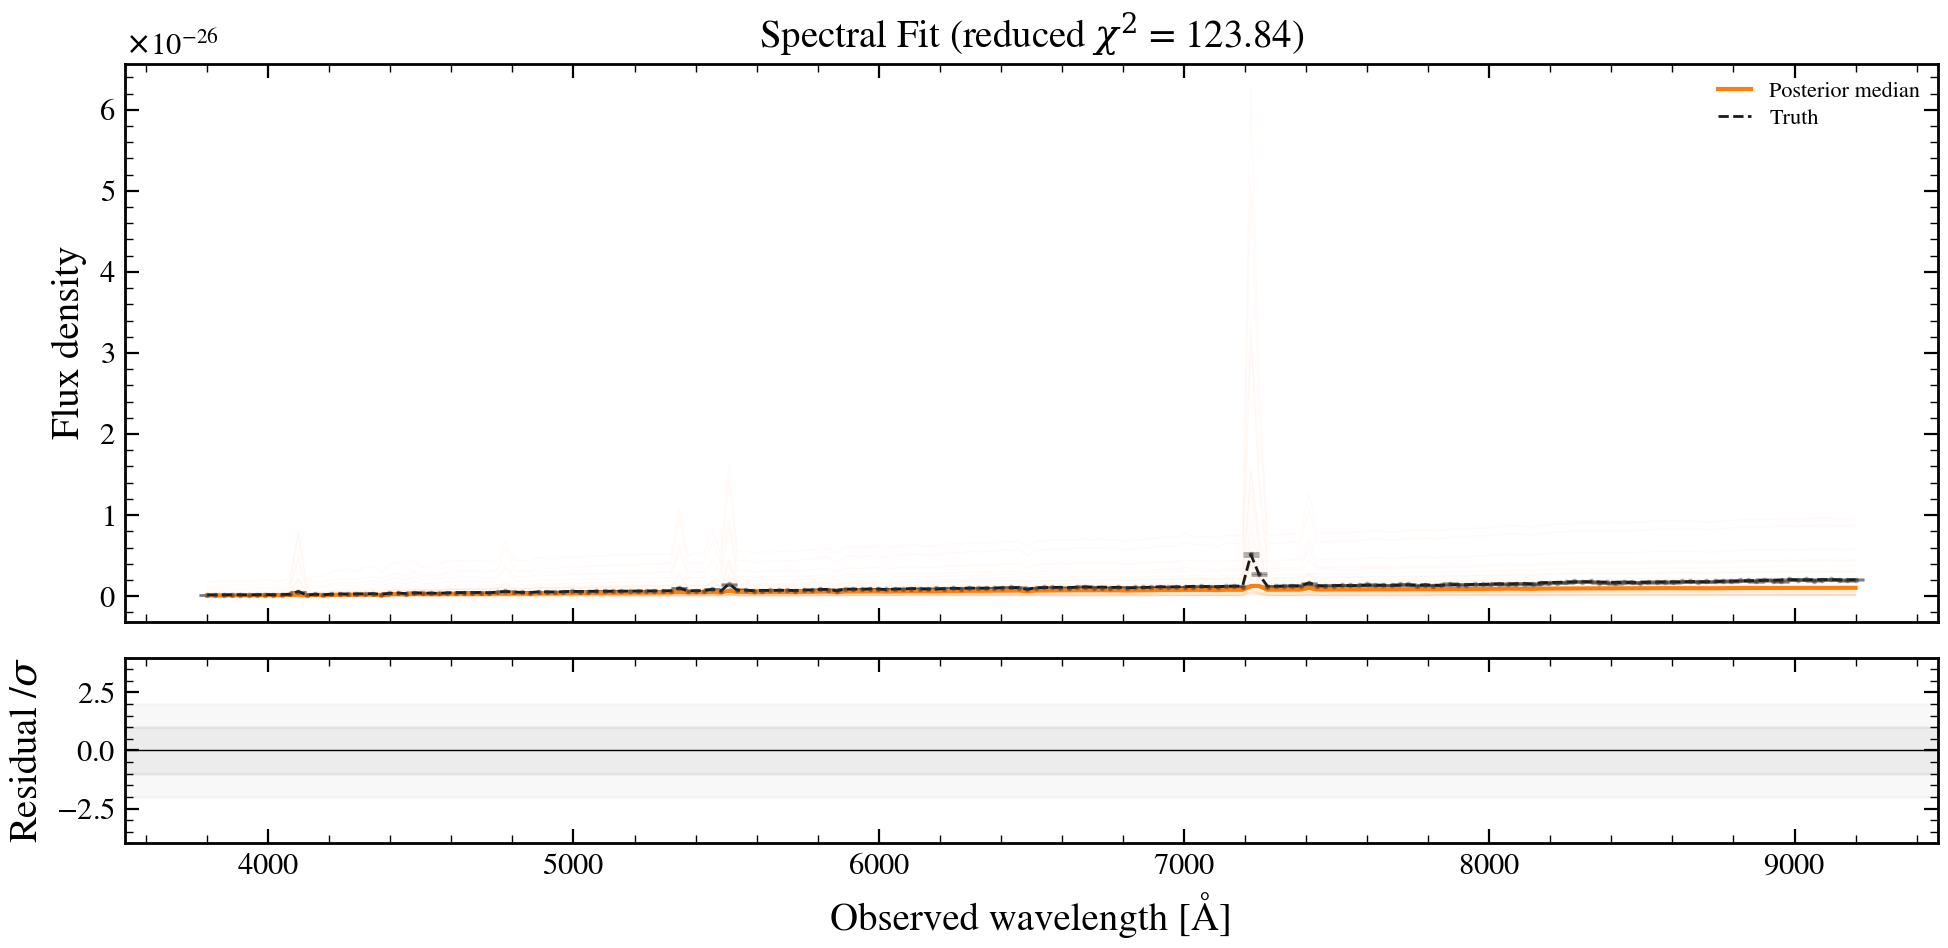

In [7]:
# --- FIGURE 2: Spectral fit + residuals ---
spec_draws = []
for i in range(50):
    idx = i % len(result_geovi_spec.samples[spec_param.free_params[0]])
    draw = {k: v[idx] for k, v in result_geovi_spec.samples.items()}
    spec_draws.append(np.array(model_param.predict_spectrum(draw)))
spec_draws = np.array(spec_draws)
spec_med = np.median(spec_draws, axis=0)

fig, (ax_f, ax_r) = plt.subplots(
    2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)
w = np.array(WAVE_OBS)
ax_f.errorbar(
    w,
    np.array(mock_spec.flux_obs),
    yerr=np.array(mock_spec.noise),
    fmt=".",
    ms=2,
    color=COLORS["data"],
    alpha=0.4,
)
for s in spec_draws[:50]:
    ax_f.plot(w, s, color=COLORS["vi"], alpha=0.03, lw=0.5)
ax_f.plot(w, spec_med, color=COLORS["vi"], lw=1.5, label="Posterior median")
ax_f.plot(w, np.array(mock_spec.flux_true), color=COLORS["truth"], lw=1, ls="--", label="Truth")
ax_f.legend(fontsize=8)
ax_f.set_ylabel("Flux density")

res = (np.array(mock_spec.flux_obs) - spec_med) / np.array(mock_spec.noise)
ax_r.scatter(w, res, s=2, c=COLORS["data"], alpha=0.5)
ax_r.axhline(0, color="k", lw=0.5)
ax_r.axhspan(-1, 1, alpha=0.1, color="grey")
ax_r.axhspan(-2, 2, alpha=0.05, color="grey")
ax_r.set_ylim(-4, 4)
ax_r.set_ylabel(r"Residual /$\sigma$")
ax_r.set_xlabel("Observed wavelength [Å]")

chi2 = np.sum(res**2) / len(res)
ax_f.set_title(f"Spectral Fit (reduced $\\chi^2$ = {chi2:.2f})")
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig02_spectral_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

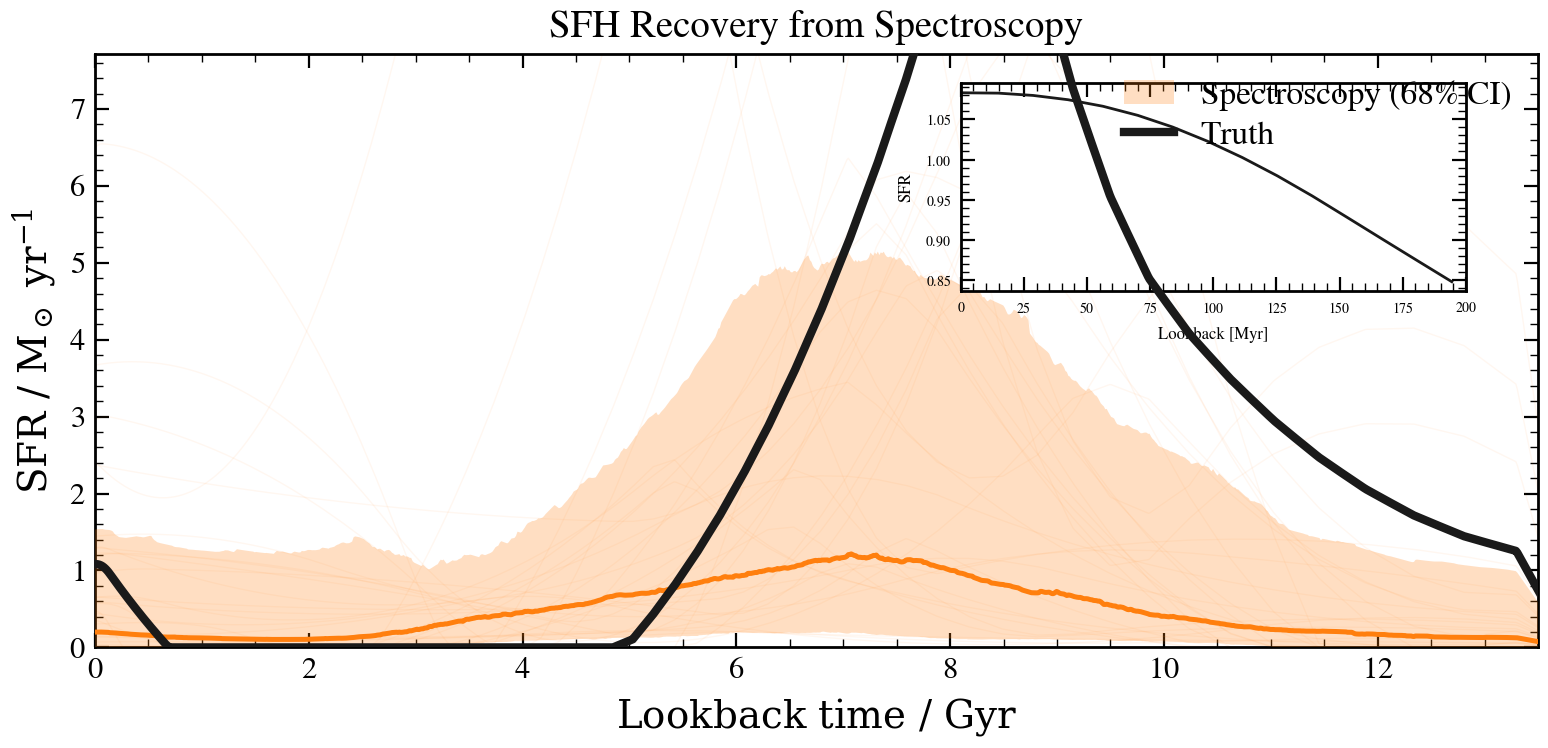

In [8]:
# --- FIGURE 3: SFH recovery ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(
    model_param,
    result_geovi_spec,
    true_params=true_param,
    ax=ax,
    color=COLORS["vi"],
    label="Spectroscopy",
    method="geoVI",
)
ax.set_title("SFH Recovery from Spectroscopy")
# 200 Myr inset
sfh_true_p = model_param.predict_sfh(true_param)
t_gyr_p = np.array(sfh_true_p["t_gyr"])
sfr_p = np.array(sfh_true_p["sfr_mean"])
inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])
mask_200 = t_gyr_p < 0.2
if hasattr(t_gyr_p, "__len__") and np.any(mask_200):
    inset.plot(t_gyr_p[mask_200] * 1e3, sfr_p[mask_200], color=COLORS["truth"], lw=1)
    inset.set_xlabel("Lookback [Myr]", fontsize=6)
    inset.set_ylabel("SFR", fontsize=6)
    inset.tick_params(labelsize=5)
    inset.set_xlim(0, 200)
fig.tight_layout()
# plt.savefig(os.path.join(FIGDIR, "fig03_sfh_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

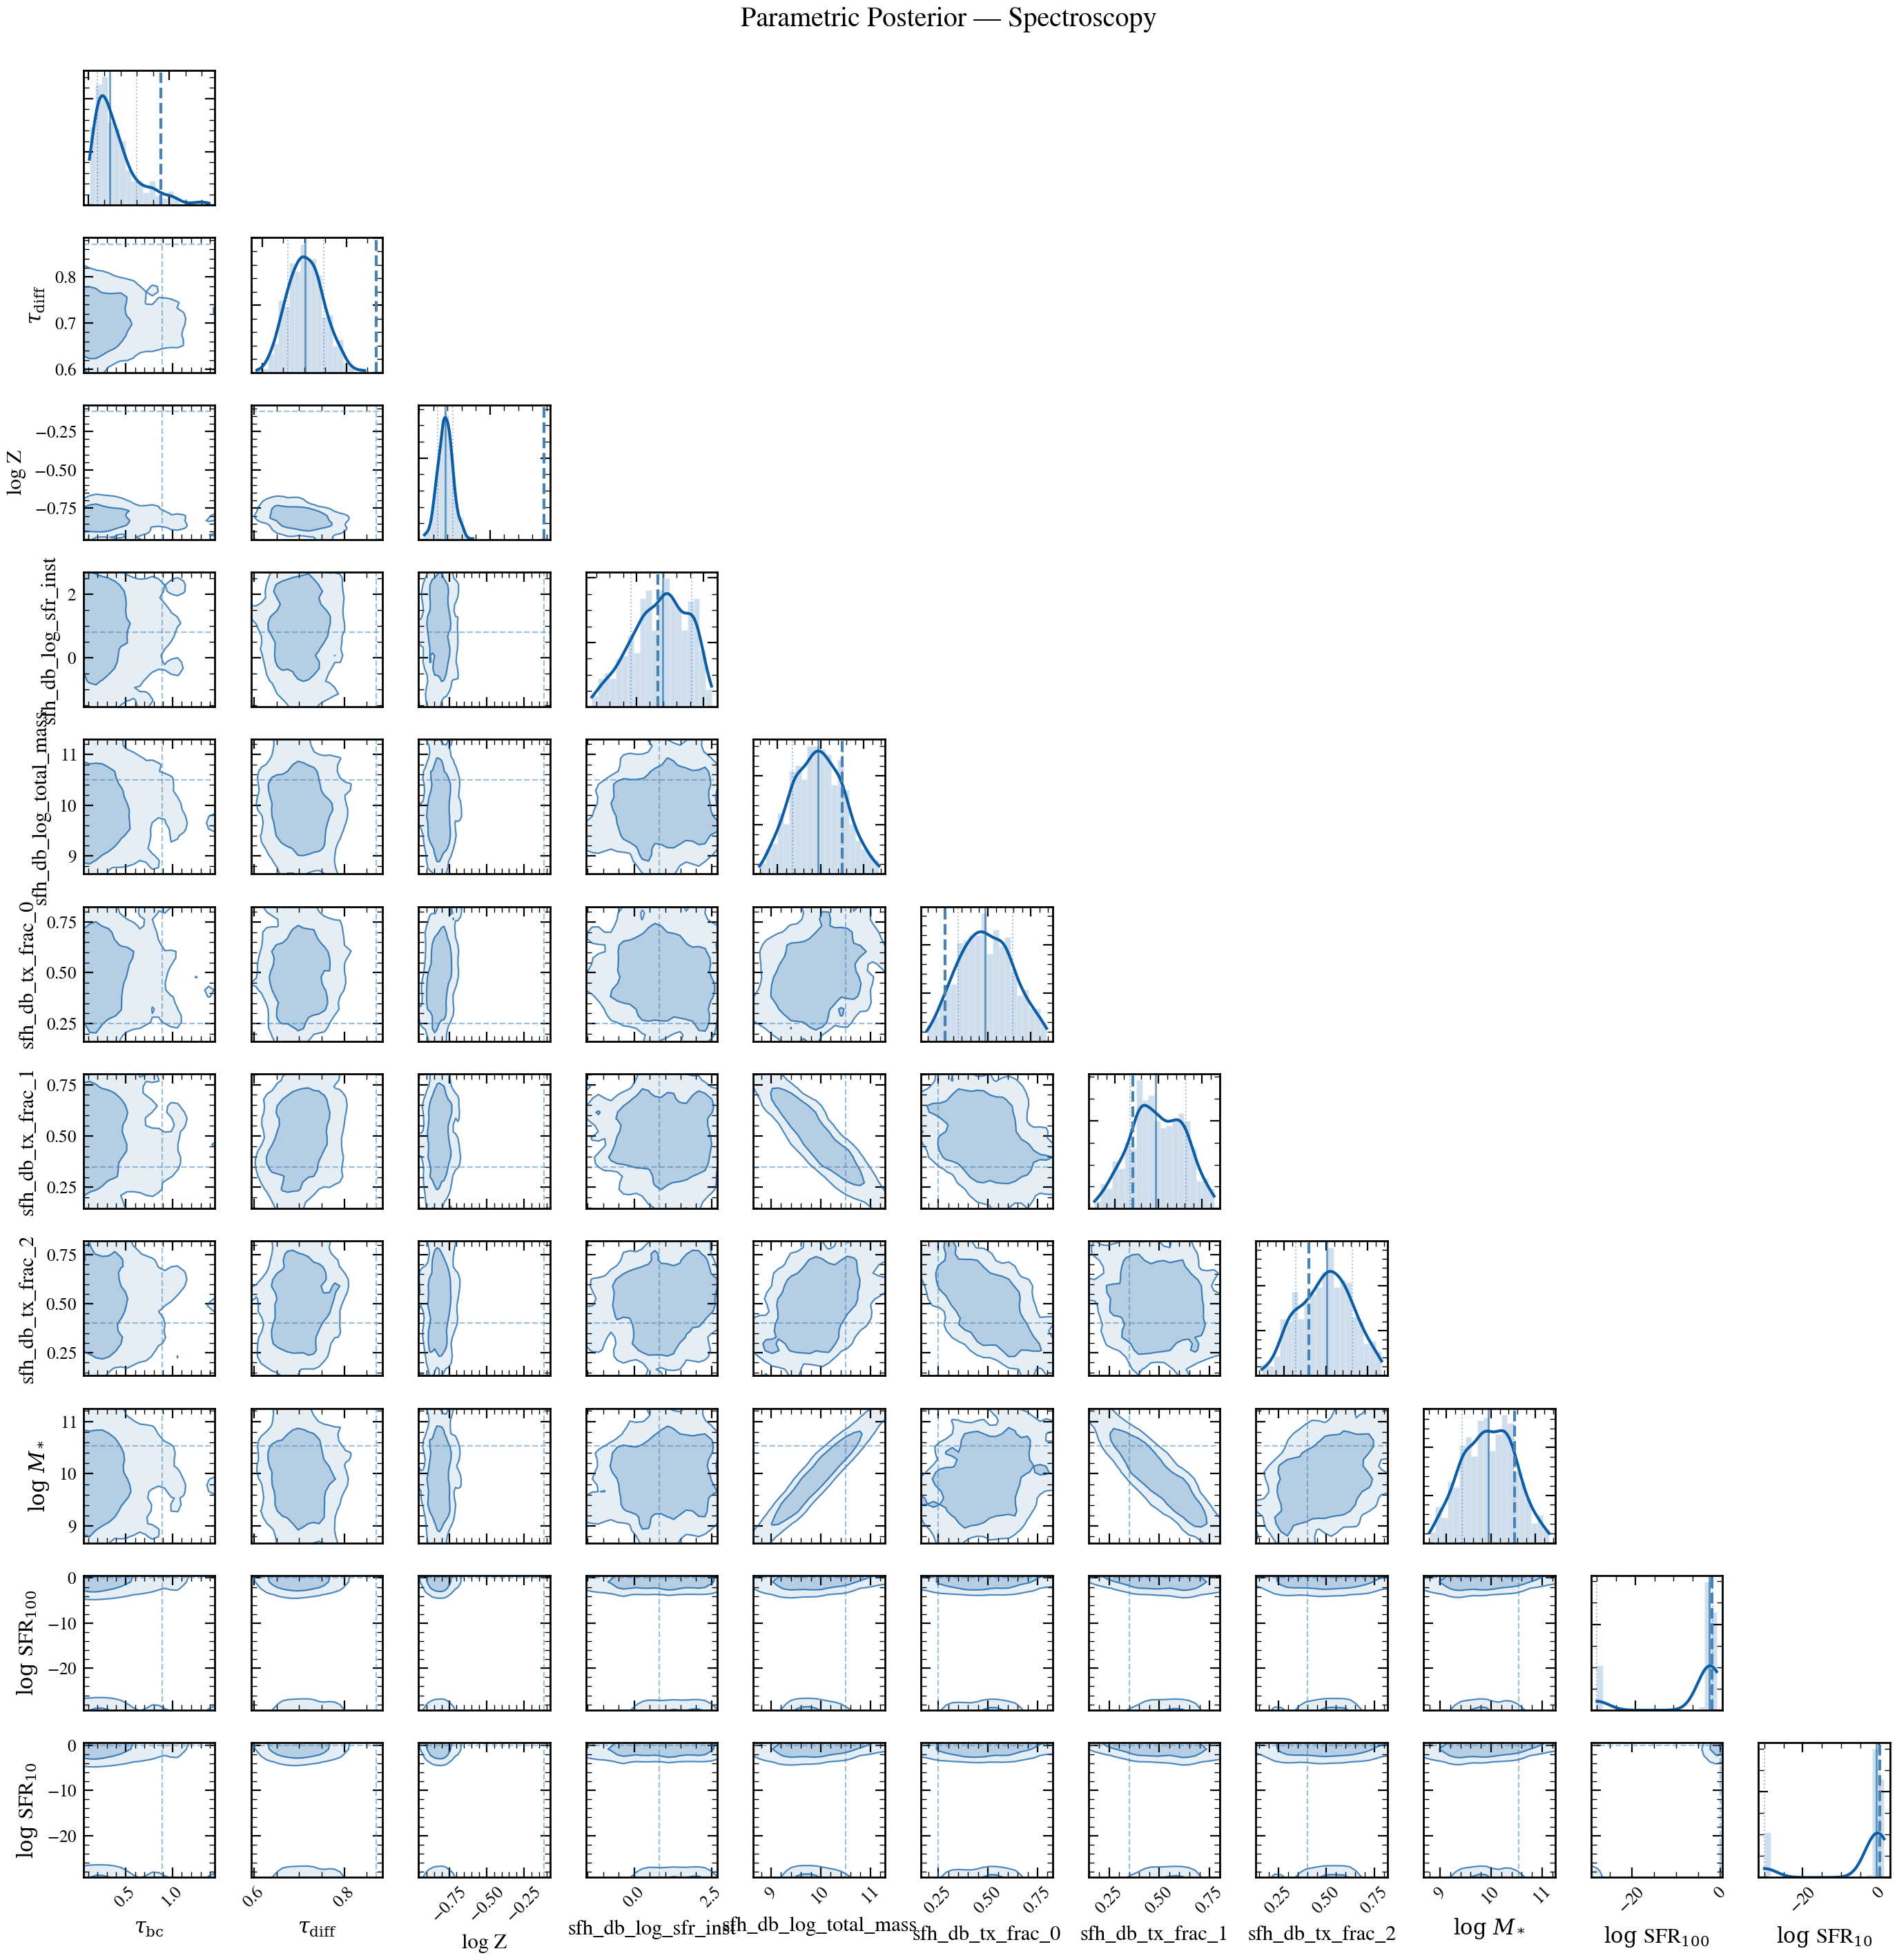

In [9]:
# --- FIGURE 4: Corner plot ---
fig = safe_corner(result_geovi_spec, truths=true_param)
if fig is not None:
    fig.suptitle("Parametric Posterior — Spectroscopy", y=1.02)
    # plt.savefig(os.path.join(FIGDIR, "fig04_corner_spec.png"), dpi=150, bbox_inches="tight")
plt.show()

## Laplace and Pathfinder: Fast Approximate Posteriors (Optional)

Laplace inverts the Hessian at MAP; Pathfinder traces the L-BFGS path
and picks the best Gaussian along it (Zhang et al. 2022). Both are much
faster than geoVI but less flexible. Set `RUN_EXPENSIVE = True` to run
the comparison below.

In [10]:
if RUN_EXPENSIVE:
    result_laplace = fitter_spec.run(
        "laplace",
        key=jax.random.PRNGKey(10),
        init_from=result_map,
        n_samples=300,
        verbose=False,
    )
    result_pathfinder = fitter_spec.run(
        "pathfinder",
        key=jax.random.PRNGKey(11),
        init_from=result_map,
        n_samples=300,
        verbose=False,
    )
    print(f"Laplace:    {result_laplace.wall_time_s:.1f}s")
    print(f"Pathfinder: {result_pathfinder.wall_time_s:.1f}s")
    print(f"geoVI:      {result_geovi_spec.wall_time_s:.1f}s")

    # --- FIGURE 4b: Corner — Laplace vs Pathfinder vs geoVI ---
    fig = plot_corner_comparison(
        [result_laplace, result_pathfinder, result_geovi_spec],
        labels=["Laplace", "Pathfinder", "geoVI"],
        colors=[COLORS["laplace"], COLORS["pathfinder"], COLORS["vi"]],
        truths=true_param,
    )
    if fig is not None:
        fig.suptitle("Laplace vs Pathfinder vs geoVI (Spectroscopy)", y=1.02)
    plt.show()

    # --- FIGURE 4c: 1D marginals comparison ---
    _free = spec_param.free_params
    _ncols = min(4, len(_free))
    _nrows = int(np.ceil(len(_free) / _ncols))
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(4 * _ncols, 3 * _nrows))
    _axes = np.array(axes).reshape(-1) if len(_free) > 1 else [axes]

    for ax, pname in zip(_axes, _free):
        tv = float(true_param[pname])
        for label, res, color, ls in [
            ("geoVI", result_geovi_spec, COLORS["vi"], "-"),
            ("Laplace", result_laplace, COLORS["laplace"], "--"),
            ("Pathfinder", result_pathfinder, COLORS["pathfinder"], "-."),
        ]:
            ax.hist(
                np.array(res.samples[pname]),
                bins=40,
                histtype="step",
                density=True,
                color=color,
                ls=ls,
                lw=1.5,
                label=label,
            )
        ax.axvline(tv, color=COLORS["truth"], lw=1.5, ls=":")
        ax.set_xlabel(pname.replace("sfh_tsnorm_", ""), fontsize=8)
        ax.set_yticks([])
    for ax in _axes[len(_free) :]:
        ax.set_visible(False)
    _axes[0].legend(fontsize=7, loc="upper right")
    fig.suptitle("1D Marginals: Laplace vs Pathfinder vs geoVI", fontsize=11)
    fig.tight_layout()
    plt.show()

    # Convergence diagnostics — parametric model
    print(
        convergence_table(
            {
                "geoVI": result_geovi_spec,
                "Laplace": result_laplace,
                "Pathfinder": result_pathfinder,
            },
            verbose=True,
        )
    )

In [11]:
# Parameter recovery table — parametric D=7
print(f"\n{'Parameter':<32s} {'True':>8s} {'Median':>8s} {'16%':>8s} {'84%':>8s} {'Status':>6s}")
print("-" * 76)
for name in spec_param.free_params:
    truth = float(true_param[name])
    lo, med, hi = np.percentile(result_geovi_spec.samples[name], [16, 50, 84])
    covered = "ok" if lo <= truth <= hi else "MISS"
    print(f"  {name:<30s} {truth:8.3f} {med:8.3f} {lo:8.3f} {hi:8.3f} {covered:>6s}")


Parameter                            True   Median      16%      84% Status
----------------------------------------------------------------------------
  dust_tau_bc                       0.893    0.266    0.113    0.599   MISS
  dust_tau_diff                     0.871    0.702    0.661    0.745   MISS
  met_logzsol                      -0.119   -0.814   -0.868   -0.764   MISS
  sfh_db_log_sfr_inst               0.800    0.968   -0.200    2.060     ok
  sfh_db_log_total_mass            10.500    9.941    9.347   10.520     ok
  sfh_db_tx_frac_0                  0.250    0.483    0.326    0.646   MISS
  sfh_db_tx_frac_1                  0.350    0.483    0.336    0.656     ok
  sfh_db_tx_frac_2                  0.400    0.505    0.319    0.659     ok


## Stochastic SFH from Spectroscopy (Optional)

Spectroscopy breaks the σ–τ degeneracy that photometry can't. The rich
spectral information constrains both the amplitude and timescale of burstiness.
Set `RUN_EXPENSIVE = True` to fit and recover the PSD parameters; see
[`16_quickstart_stochastic.py`](16_quickstart_stochastic.py) for a dedicated
stochastic showcase.

In [12]:
if RUN_EXPENSIVE:
    # Stochastic model
    spec_stoch = Parameters(
        sfh_dbp_log_total_mass=Uniform(8, 12),
        sfh_dbp_tx_frac_0=Uniform(0.05, 0.95),
        sfh_dbp_tx_frac_1=Uniform(0.05, 0.95),
        sfh_dbp_tx_frac_2=Uniform(0.05, 0.95),
        sfh_field_psd_sigma=Uniform(0.1, 4.0),
        sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
        met_logzsol=Uniform(-2.0, 0.2),
        dust_tau_bc=Uniform(0.0, 2.0),
        dust_tau_diff=Uniform(0.0, 1.5),
        dust_slope=Fixed(-0.7),
        redshift=Fixed(0.1),
        mean_sfh_type=["dense_basis", "field"],
        n_grid=64,
    )
    model_stoch = SEDModel(spec_stoch, ssp_data, observation=obs_joint)
    model_stoch_spec = SEDModel(spec_stoch, ssp_data, observation=obs_spec)

    true_stoch = spec_stoch.sample(jax.random.PRNGKey(77))
    # Override to a typical star-forming galaxy with burstiness
    true_stoch = {**true_stoch}
    true_stoch["sfh_dbp_log_total_mass"] = jnp.array(10.5)
    true_stoch["sfh_dbp_tx_frac_0"] = jnp.array(0.25)
    true_stoch["sfh_dbp_tx_frac_1"] = jnp.array(0.35)
    true_stoch["sfh_dbp_tx_frac_2"] = jnp.array(0.4)
    true_stoch["sfh_field_psd_sigma"] = jnp.array(2.0)
    true_stoch["sfh_field_psd_tau_myr"] = jnp.array(20.0)

    mock_spec_s = model_stoch.mock_spectrum(
        true_stoch, WAVE_OBS, snr=30.0, key=jax.random.PRNGKey(78)
    )
    mock_phot_s = model_stoch.mock(true_stoch, snr=20.0, key=jax.random.PRNGKey(79))

    fitter_stoch_spec = Fitter(model_stoch_spec, mock_spec_s.flux_obs, mock_spec_s.noise)

    t0_compile = time.perf_counter()
    fitter_stoch_spec.compile(verbose=False)
    t_compile = time.perf_counter() - t0_compile

    _ = fitter_stoch_spec.run("map", n_steps=500, verbose=False)

    t0 = time.perf_counter()
    result_stoch_spec = fitter_stoch_spec.run(
        "vi",
        n_iterations=8,
        n_samples=4,
        n_posterior_samples=500,
        verbose=False,
    )
    t_run = time.perf_counter() - t0
    print(f"Stochastic spectroscopic fit (D = {spec_stoch.n_free}):")
    print(f"  XLA compile: {t_compile:.1f}s (one-time, cached on disk)")
    print(f"  vi (geoVI): {t_run:.1f}s <- runtime per galaxy")

    # --- FIGURE 5: Bursty SFH recovery from spectroscopy ---
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_sfh(
        model_stoch,
        result_stoch_spec,
        true_params=true_stoch,
        ax=ax,
        color=COLORS["vi"],
        label="Spectroscopy",
        method="geoVI",
        show_mean_sfh=True,
    )
    ax.set_title(f"Bursty SFH Recovery from Spectroscopy (D = {spec_stoch.n_free})")
    # 200 Myr inset
    sfh_true_s = model_stoch.predict_sfh(true_stoch)
    t_gyr_s = np.array(sfh_true_s["t_gyr"])
    sfr_full_s = np.array(sfh_true_s["sfr_full"])
    inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])
    mask_200 = t_gyr_s < 0.2
    if hasattr(t_gyr_s, "__len__") and np.any(mask_200):
        inset.plot(t_gyr_s[mask_200] * 1e3, sfr_full_s[mask_200], color=COLORS["truth"], lw=1)
        inset.set_xlabel("Lookback [Myr]", fontsize=6)
        inset.set_ylabel("SFR", fontsize=6)
        inset.tick_params(labelsize=5)
        inset.set_xlim(0, 200)
    fig.tight_layout()
    plt.show()

    # --- FIGURE 6: PSD parameter corner ---
    psd_params = ["sfh_field_psd_sigma", "sfh_field_psd_tau_myr"]
    fig = safe_corner(result_stoch_spec, truths=true_stoch, params=psd_params)
    if fig is not None:
        fig.suptitle("PSD Parameters — Spectroscopy Constrains Both σ and τ", y=1.02)
    plt.show()

    # --- FIGURE 7: Photometry vs Spectroscopy (stochastic) ---
    model_stoch_phot = SEDModel(spec_stoch, ssp_data, observation=obs_phot)
    fitter_stoch_phot = Fitter(model_stoch_phot, mock_phot_s.flux_obs, mock_phot_s.noise)
    _ = fitter_stoch_phot.run("map", n_steps=500, verbose=False)
    result_stoch_phot = fitter_stoch_phot.run(
        "vi",
        n_iterations=8,
        n_samples=4,
        n_posterior_samples=500,
        verbose=False,
    )

    phys_params = [p for p in spec_stoch.free_params if "xi" not in p]
    fig = plot_corner_comparison(
        [result_stoch_phot, result_stoch_spec],
        labels=["Photometry (5 bands)", "Spectroscopy (200 px)"],
        colors=[COLORS["rt"], COLORS["vi"]],
        truths=true_stoch,
        params=phys_params,
    )
    if fig is not None:
        fig.suptitle("Photometry vs Spectroscopy — Physical Parameters", y=1.02)
    plt.show()

    fig = plot_corner_comparison(
        [result_stoch_phot, result_stoch_spec],
        labels=["Photometry", "Spectroscopy"],
        colors=[COLORS["rt"], COLORS["vi"]],
        truths=true_stoch,
        params=psd_params,
    )
    if fig is not None:
        fig.suptitle("PSD Recovery: Spectroscopy Breaks the σ–τ Degeneracy", y=1.02)
    plt.show()

    # CI width comparison table
    print("\n  Parameter                  | Phot CI   | Spec CI   | Improvement")
    print("  " + "-" * 65)
    for p in phys_params:
        s_phot = np.array(result_stoch_phot.samples[p])
        s_spec = np.array(result_stoch_spec.samples[p])
        w_phot = np.percentile(s_phot, 84) - np.percentile(s_phot, 16)
        w_spec = np.percentile(s_spec, 84) - np.percentile(s_spec, 16)
        ratio = w_phot / max(w_spec, 1e-10)
        print(f"  {p:<28s} | {w_phot:>7.3f}  | {w_spec:>7.3f}  | {ratio:>5.1f}×")

## SNR Dependence (Optional)

In [13]:
if RUN_EXPENSIVE:
    snr_results = {}
    for snr in [10, 30, 100]:
        mock_snr = model_param.mock_spectrum(
            true_param, WAVE_OBS, snr=float(snr), key=jax.random.PRNGKey(snr)
        )
        fitter_snr = Fitter(model_param_spec, mock_snr.flux_obs, mock_snr.noise)
        _ = fitter_snr.run("map", n_steps=500, verbose=False)
        res_snr = fitter_snr.run(
            "vi",
            n_iterations=8,
            n_samples=4,
            n_posterior_samples=400,
            verbose=False,
        )
        snr_results[snr] = res_snr
        print(f"SNR = {snr}: {res_snr.wall_time_s:.1f}s")

    # --- FIGURE 9: SFH recovery at 3 SNR values ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, snr in zip(axes, [10, 30, 100]):
        plot_sfh(
            model_param,
            snr_results[snr],
            true_params=true_param,
            ax=ax,
            color=COLORS["vi"],
            label=f"SNR = {snr}",
            method="geoVI",
        )
        ax.set_title(f"SNR = {snr}")
    fig.suptitle("SFH Recovery vs Signal-to-Noise Ratio", fontsize=11)
    fig.tight_layout()
    plt.show()

## Feature Accessibility vs Redshift (Optional)

As redshift increases, different spectral features shift through the
observed window. At z > 5, the Lyman break enters the NIR — JWST territory.

In [14]:
if RUN_EXPENSIVE:
    # --- FIGURE 10: Rest-frame features at z = 0.1, 1.0, 6.0 ---
    redshifts = [0.1, 1.0, 6.0]
    surveys = ["SDSS (3800–9200 Å)", "DESI (3600–9800 Å)", "JWST NIRSpec (6000–53000 Å)"]
    windows = [(3800, 9200), (3600, 9800), (6000, 53000)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, z, survey, (wlo, whi) in zip(axes, redshifts, surveys, windows):
        # Mark features in rest-frame
        for feat_name, feat_wave in SPECTRAL_FEATURES.items():
            w_obs = feat_wave * (1 + z)
            if wlo < w_obs < whi:
                ax.axvline(w_obs, color="grey", ls=":", lw=0.5, alpha=0.5)
                ax.text(
                    w_obs,
                    0.95,
                    feat_name,
                    fontsize=5,
                    ha="center",
                    va="top",
                    rotation=90,
                    transform=ax.get_xaxis_transform(),
                    color="grey",
                )

        ax.axvspan(wlo, whi, alpha=0.1, color=COLORS["vi"])
        ax.set_xlabel("Observed wavelength [Å]")
        ax.set_title(f"z = {z} — {survey}", fontsize=9)
        ax.set_xlim(wlo * 0.9, whi * 1.1)

    fig.suptitle("Spectral Feature Accessibility vs Redshift", fontsize=11)
    fig.tight_layout()
    plt.show()

## Summary & Next Steps

**What we've shown:**
- Parametric (D=7) and stochastic (D=10+) SFH models fit spectroscopy in seconds–minutes.
- Posterior-predictive residuals reveal systematics; χ² ≈ 1 indicates good fit.
- Spectroscopy breaks age–dust–Z degeneracy; photometry alone cannot.
- SNR and redshift control feature accessibility and constraint power.

**For a deeper dive:** see [`07_fitting_photometry.py`](07_fitting_photometry.py)
for photometry setup and masking checklist, [`09_degeneracies.py`](09_degeneracies.py)
for Fisher-matrix degeneracy analysis, and
[`15_emission_line_measurements.py`](15_emission_line_measurements.py)
for emission-line marginalization.